# Core Overview
___

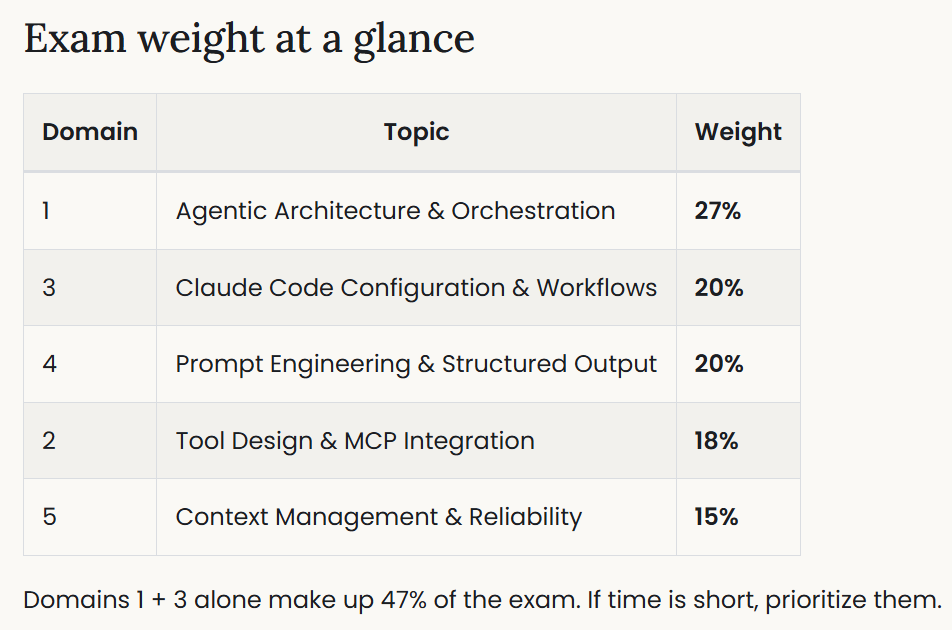

Most wrong answers on the CCA are architecturally plausible but miss a single key trade-off. The exam rewards one consistent mental model:

> **Deterministic > probabilistic**. When the exam asks how to enforce ordering, compliance, or policy rules — the answer is always programmatic (hooks, prerequisites, schema validation), never prompt-based (instructions, few-shot examples). Prompts guide; code enforces.

Everything else flows from this:

* `stop_reason` over text parsing
* `Programmatic prerequisites` over system prompt instructions
* `isRetryable flags` over generic retry logic
* `JSON schema + strict: true` over "ask Claude nicely"
* `Scoped tools` over giving agents everything

___

## Agentic Loop
Claude evaluates your prompt, calls tools to take action, receives the results, and repeats until the task is complete.

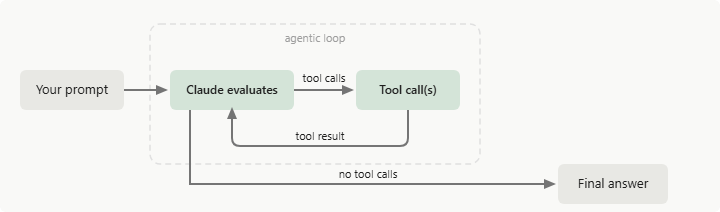

### SDK Capabilities

* `glob` is used when you are seaprching for things with a certain file name or file path
* `grep` is when you are searching for something within files

### Sessions

In the Claude Agent SDK, a **session** is the accumulated conversation history: the prompt, every tool call, every tool result, and every response.  

The SDK writes this transcript to local disk automatically (under ~/.claude/projects/<encoded-cwd>/*.jsonl by default), which works well on a single developer machine but breaks down in fleet deployments: a session file written on one container simply does not exist on another

### Progressive Summarization Trap Domain - *Context Management & Reliability*


**Progressive summarization trap** is where each summarization pass loses nuance, and after several rounds, critical details like a negotiated dollar amount or a customer's stated preference are diluted beyond usefulness. Because Claude is stateless, the model only knows what your application includes in the current request; if a fact was compressed out of the summary, it is simply gone from the model's perspective.

**The reliable pattern is a persistent case facts block: a structured section** (order numbers, amounts, dates, statuses, customer-stated expectations, decisions made) **that is assembled into every prompt outside the summarized history and is never itself summarized**, only updated as new facts emerge. This gives you tiered context management: recent turns in full, older turns as summaries, and critical facts in a durable block. It works because it separates compressible narrative from incompressible transactional state.